# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [12]:
# 실습 준비 코드를 작성하세요.
# 실습 준비 코드를 작성하세요.

import pandas as pd


# 1~2. CSV 파일 불러오기
subscriptions = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_subscriptions.csv'
)

feature_usage = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_feature_usage.csv'
)


# 3. 행/열 개수, 상위 5개 행 확인
print("=== subscriptions ===")
print(subscriptions.shape)
display(subscriptions.head())

print("=== feature_usage ===")
print(feature_usage.shape)
display(feature_usage.head())


# 4. 자료형과 결측치 확인
print("=== subscriptions ===")
print(subscriptions.dtypes)
print(subscriptions.isna().sum())

print("\n=== feature_usage ===")
print(feature_usage.dtypes)
print(feature_usage.isna().sum())


# 5. 날짜형 변환
subscriptions['start_date'] = pd.to_datetime(
    subscriptions['start_date'], errors='coerce'
)

subscriptions['end_date'] = pd.to_datetime(
    subscriptions['end_date'], errors='coerce'
)

feature_usage['usage_date'] = pd.to_datetime(
    feature_usage['usage_date'], errors='coerce'
)


# 6. 구독 ID 고유 개수 / 기능 사용 이벤트 행 수
print("구독 ID 고유 개수:",
      subscriptions['subscription_id'].nunique())

print("기능 사용 이벤트 행 수:",
      len(feature_usage))


# 7. usage_id 중복 개수
duplicate_usage_id = feature_usage['usage_id'].duplicated().sum()

print("usage_id 중복 개수:", duplicate_usage_id)

=== subscriptions ===
(5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


=== feature_usage ===
(25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


=== subscriptions ===
subscription_id        str
account_id             str
start_date             str
end_date               str
plan_tier              str
seats                int64
mrr_amount           int64
arr_amount           int64
is_trial              bool
upgrade_flag          bool
downgrade_flag        bool
churn_flag            bool
billing_frequency      str
auto_renew_flag       bool
dtype: object
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

=== feature_usage ===
usage_id                 str
subscription_id          str
usage_date               str
feature_name             str
usage_count            int64
usage_duration_secs    int64
error_count 

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  

같은 구독에서 가능 사용 이벤트가 여러 번 발생할 수 있다.
중복 계산이 될 위험성이 있다.

**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요? 

기능 사용 -> 유료 구독 구간, 전환율은 약 84.42%, 이탈 구독 수는 774개

**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  

100% 이탈율 = 1 - 전환율로 계산

**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

없다. 퍼널은 사용자가 많이 줄어든 위치를 보여주지만,
가격, 성능, 기능부족 등 어떤 이유로 줄었는지는 원인 파악이 추가적으로 필요하다.


#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

,stage,count
0,Started,5000
1,Used,4967
2,Paid,4193
3,Retained,3788


,stage,count,previous_count,conversion_rate,churn_rate,churn_count
0,Started,5000,NaN,NaN,NaN,NaN
1,Used,4967,5000.0,0.993400,0.006600,33.0
2,Paid,4193,4967.0,0.844172,0.155828,774.0
3,Retained,3788,4193.0,0.903410,0.096590,405.0


,stage,count,previous_count,conversion_rate,churn_rate,churn_count
0,Started,5000,NaN,NaN,NaN,NaN
1,Used,4967,5000.0,99.34,0.66,33.0
2,Paid,4193,4967.0,84.42,15.58,774.0
3,Retained,3788,4193.0,90.34,9.66,405.0


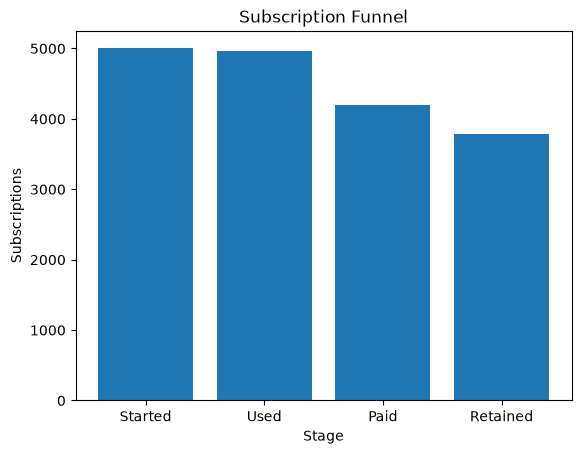

전환율이 가장 낮은 단계: Paid
전환율: 84.42 %


In [10]:
# 필수 1 코드를 작성하세요.
# 1. 전체 구독 ID
started_ids = set(subscriptions['subscription_id'])

# 2. 기능 사용 기록이 있는 구독 ID
used_ids = started_ids & set(feature_usage['subscription_id'])

# 3. 기능 사용 + 유료 구독
paid_ids = used_ids & set(
    subscriptions.loc[
        subscriptions['mrr_amount'] > 0,
        'subscription_id'
    ]
)

# 4. 유료 구독 중 종료일이 없는 구독
retained_paid_ids = paid_ids & set(
    subscriptions.loc[
        subscriptions['end_date'].isna(),
        'subscription_id'
    ]
)


# 5. Funnel 데이터프레임
funnel = pd.DataFrame({
    'stage': ['Started', 'Used', 'Paid', 'Retained'],
    'count': [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_paid_ids)
    ]
})

display(funnel)


# 이전 단계 구독 수
funnel['previous_count'] = funnel['count'].shift(1)

# 전환율
funnel['conversion_rate'] = (
    funnel['count'] / funnel['previous_count']
)

# 이탈률
funnel['churn_rate'] = 1 - funnel['conversion_rate']

# 이탈 구독 수
funnel['churn_count'] = (
    funnel['previous_count'] - funnel['count']
)

display(funnel)


funnel['conversion_rate'] = (
    funnel['conversion_rate'] * 100
).round(2)

funnel['churn_rate'] = (
    funnel['churn_rate'] * 100
).round(2)

display(funnel)



import matplotlib.pyplot as plt

plt.bar(funnel['stage'], funnel['count'])

plt.xlabel('Stage')
plt.ylabel('Subscriptions')
plt.title('Subscription Funnel')

plt.show()


lowest = funnel.loc[funnel['conversion_rate'].idxmin()]

print("전환율이 가장 낮은 단계:", lowest['stage'])
print("전환율:", lowest['conversion_rate'], "%")


### 필수 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  

enterprise 요즘제 기능 사용 -> 유로 구독 구간, 전환율은 84.19%

**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  

전체 겨로가에서는 쉽게 볼 수 없는 특정 요금제의 상대적으로 낮은 구간을 찾을 수 있어 개선 대상을 더 구체적으로 정할 수 있음

**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  

아니다 기능 사용에서 유로ㅛ 구독으로 이어지는 전환율은 세 요금제 모두 84%정도로 차이가 적다.

**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

체험 종료 데이터, 이탈 사유, 고객 문의

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

In [11]:
# 필수 2 코드를 작성하세요.
import numpy as np 
# 요금제별 퍼널 계산 함수
def calculate_segment_funnel(df, plan_name):

    temp = df[df["plan"] == plan_name]

    # 아래 4단계는 1번 실습에서 사용한 조건과 동일하게 작성
    step1 = temp["user_id"].nunique()

    step2 = temp[temp["step2"] == 1]["user_id"].nunique()
    step3 = temp[temp["step3"] == 1]["user_id"].nunique()
    step4 = temp[temp["step4"] == 1]["user_id"].nunique()

    counts = [step1, step2, step3, step4]

    rates = [
        np.nan,
        step2 / step1,
        step3 / step2,
        step4 / step3
    ]

    return pd.DataFrame({
        "plan": plan_name,
        "stage": ["Step1", "Step2", "Step3", "Step4"],
        "users": counts,
        "conversion_rate": rates
    })

plans = df["plan"].dropna().unique()

results = []

for plan in plans:
    results.append(
        calculate_segment_funnel(df, plan)
    )

plan_funnel = pd.concat(results, ignore_index=True)

display(plan_funnel)


plot_df = plan_funnel.dropna(subset=["conversion_rate"])

for plan in plans:
    temp = plot_df[plot_df["plan"] == plan]

    plt.bar(
        temp["stage"],
        temp["conversion_rate"],
        alpha=0.6,
        label=plan
    )

plt.ylabel("Conversion Rate")
plt.title("Plan Funnel Conversion Rate")
plt.legend()
plt.show()

lowest = plot_df.loc[
    plot_df["conversion_rate"].idxmin()
]

print("가장 낮은 전환 구간")
print(lowest)






NameError: name 'df' is not defined

### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

usage_id 중복 제거 전: 25000
usage_id 중복 제거 후: 24979

=== billing_funnel ===


,billing_frequency,stage,transition,count,conversion_rate,dropoff_rate
0,monthly,Started,-,2539,NaN,NaN
1,monthly,Used,Started → Used,2520,0.992517,0.007483
2,monthly,Paid,Used → Paid,2120,0.841270,0.158730
3,monthly,Retained,Paid → Retained,1930,0.910377,0.089623
4,annual,Started,-,2461,NaN,NaN
5,annual,Used,Started → Used,2447,0.994311,0.005689
6,annual,Paid,Used → Paid,2073,0.847160,0.152840
7,annual,Retained,Paid → Retained,1858,0.896286,0.103714


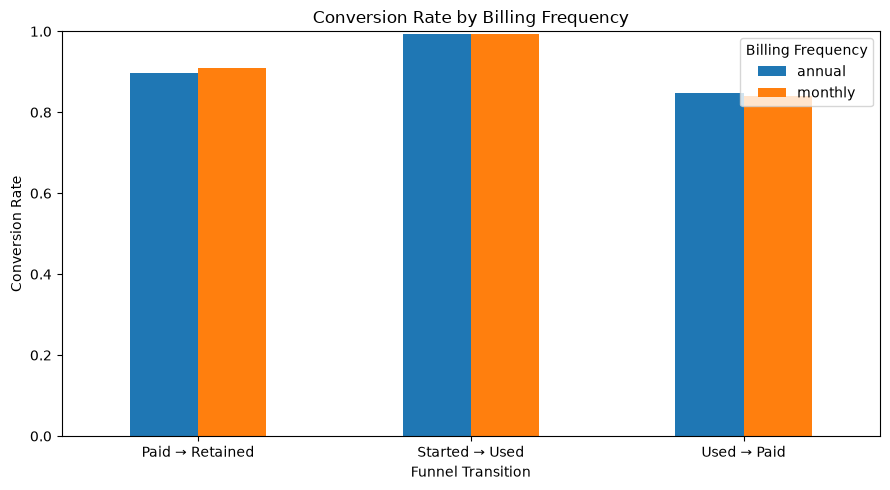


=== 가장 낮은 전환율 조합 ===
결제 주기: monthly
구간: Used → Paid
전환율: 84.13%
이탈률: 15.87%

=== 우선 점검 대상 ===
monthly / Used → Paid

=== 개선 가설 ===
기능 사용 후 유료 전환 과정에서 가격이나 결제 조건이 전환을 방해하고 있을 가능성이 있다. 가격 안내와 유료 전환 메시지를 우선 점검할 수 있다.

=== 분석의 한계 ===
결제 주기별 전환율 차이는 확인할 수 있지만, 이 결과만으로 결제 주기가 이탈의 직접적인 원인이라고 판단할 수는 없다.
요금제(plan_tier), 이용 기간, 기능 사용 빈도, 구독 시작 시점, 업그레이드·다운그레이드 여부, 해지 시점 등의 요인이 함께 영향을 줄 수 있다.
따라서 결제 주기별 사용자 특성, 기능 사용량, 요금제, 해지 시점 및 해지 사유 등의 데이터를 추가로 확인해야 한다.

=== Q1 ===
전환율이 가장 낮은 조합은 monthly 결제 주기의 Used → Paid 구간이다.

=== Q2 ===
해당 구간의 전환율은 84.13%, 이탈률은 15.87%이다.

=== Q3 ===
아니다. 퍼널 분석은 결제 주기별 전환율 차이를 보여줄 뿐, 결제 주기가 이탈의 원인이라는 인과관계를 증명하지 않는다. 다른 사용자 특성과 행동 데이터를 추가로 확인해야 한다.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CSV 불러오기
# ============================================================

subscriptions = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_subscriptions.csv'
)

feature_usage = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_feature_usage.csv'
)


# ============================================================
# 2. 날짜형 변환
# ============================================================

subscriptions['start_date'] = pd.to_datetime(
    subscriptions['start_date'],
    errors='coerce'
)

subscriptions['end_date'] = pd.to_datetime(
    subscriptions['end_date'],
    errors='coerce'
)

feature_usage['usage_date'] = pd.to_datetime(
    feature_usage['usage_date'],
    errors='coerce'
)


# ============================================================
# 3. usage_id 중복 제거
# ============================================================

feature_usage_clean = feature_usage.drop_duplicates(
    subset='usage_id'
).copy()

print("usage_id 중복 제거 전:", len(feature_usage))
print("usage_id 중복 제거 후:", len(feature_usage_clean))


# ============================================================
# 4. 결제 주기별 퍼널 계산 함수
# ============================================================

def calculate_segment_funnel(segment_col, segment_value):

    # 해당 결제 주기 구독만 선택
    sub = subscriptions[
        subscriptions[segment_col] == segment_value
    ].copy()

    # 1단계: Started
    started_ids = set(
        sub['subscription_id'].unique()
    )

    # 2단계: Used
    used_ids = set(
        feature_usage_clean.loc[
            feature_usage_clean['subscription_id'].isin(started_ids)
            & (feature_usage_clean['usage_count'] > 0),
            'subscription_id'
        ].unique()
    )

    # 3단계: Paid
    paid_ids = set(
        sub.loc[
            sub['subscription_id'].isin(used_ids)
            & (sub['mrr_amount'] > 0),
            'subscription_id'
        ].unique()
    )

    # 4단계: Retained
    retained_ids = set(
        sub.loc[
            sub['subscription_id'].isin(paid_ids)
            & (sub['churn_flag'] == False),
            'subscription_id'
        ].unique()
    )

    counts = [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_ids)
    ]

    stages = [
        'Started',
        'Used',
        'Paid',
        'Retained'
    ]

    transitions = [
        '-',
        'Started → Used',
        'Used → Paid',
        'Paid → Retained'
    ]

    conversion_rates = [
        None,
        counts[1] / counts[0] if counts[0] > 0 else None,
        counts[2] / counts[1] if counts[1] > 0 else None,
        counts[3] / counts[2] if counts[2] > 0 else None
    ]

    dropoff_rates = [
        None,
        1 - conversion_rates[1] if conversion_rates[1] is not None else None,
        1 - conversion_rates[2] if conversion_rates[2] is not None else None,
        1 - conversion_rates[3] if conversion_rates[3] is not None else None
    ]

    return pd.DataFrame({
        'billing_frequency': segment_value,
        'stage': stages,
        'transition': transitions,
        'count': counts,
        'conversion_rate': conversion_rates,
        'dropoff_rate': dropoff_rates
    })


# ============================================================
# 5. monthly / annual 퍼널 계산
# ============================================================

monthly_funnel = calculate_segment_funnel(
    'billing_frequency',
    'monthly'
)

annual_funnel = calculate_segment_funnel(
    'billing_frequency',
    'annual'
)


# ============================================================
# 6. billing_funnel 생성
# ============================================================

billing_funnel = pd.concat(
    [monthly_funnel, annual_funnel],
    ignore_index=True
)

print("\n=== billing_funnel ===")
display(billing_funnel)


# ============================================================
# 7. 결제 주기별 전환율 그래프
# ============================================================

plot_df = billing_funnel[
    billing_funnel['stage'] != 'Started'
].copy()

pivot_df = plot_df.pivot(
    index='transition',
    columns='billing_frequency',
    values='conversion_rate'
)

pivot_df.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Conversion Rate by Billing Frequency')
plt.xlabel('Funnel Transition')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Billing Frequency')
plt.tight_layout()
plt.show()


# ============================================================
# 8. 가장 낮은 전환율 조합 찾기
# ============================================================

valid_funnel = billing_funnel.dropna(
    subset=['conversion_rate']
)

lowest = valid_funnel.loc[
    valid_funnel['conversion_rate'].idxmin()
]

print("\n=== 가장 낮은 전환율 조합 ===")

print(
    "결제 주기:",
    lowest['billing_frequency']
)

print(
    "구간:",
    lowest['transition']
)

print(
    f"전환율: {lowest['conversion_rate']:.2%}"
)

print(
    f"이탈률: {lowest['dropoff_rate']:.2%}"
)


# ============================================================
# 9. 개선 가설
# ============================================================

stage = lowest['stage']

if stage == 'Used':

    hypothesis = (
        "구독 시작 후 실제 기능 사용까지 진입 장벽이 있을 수 있다. "
        "온보딩 과정이나 핵심 기능 안내를 강화하면 "
        "기능 사용 전환율이 개선될 가능성이 있다."
    )

elif stage == 'Paid':

    hypothesis = (
        "기능 사용 후 유료 전환 과정에서 가격이나 결제 조건이 "
        "전환을 방해하고 있을 가능성이 있다. "
        "가격 안내와 유료 전환 메시지를 우선 점검할 수 있다."
    )

elif stage == 'Retained':

    hypothesis = (
        "유료 전환 이후 유지 단계에서 이탈이 상대적으로 많이 발생할 수 있다. "
        "갱신 시점의 사용자 경험과 해지 이유를 확인하고 "
        "리텐션 전략을 개선할 필요가 있다."
    )

else:

    hypothesis = (
        "해당 단계에서 발생하는 사용자 행동을 "
        "추가로 확인할 필요가 있다."
    )


print("\n=== 우선 점검 대상 ===")

print(
    f"{lowest['billing_frequency']} / "
    f"{lowest['transition']}"
)

print("\n=== 개선 가설 ===")
print(hypothesis)


# ============================================================
# 10. 분석 한계
# ============================================================

print("\n=== 분석의 한계 ===")

print(
    "결제 주기별 전환율 차이는 확인할 수 있지만, "
    "이 결과만으로 결제 주기가 이탈의 직접적인 원인이라고 "
    "판단할 수는 없다."
)

print(
    "요금제(plan_tier), 이용 기간, 기능 사용 빈도, "
    "구독 시작 시점, 업그레이드·다운그레이드 여부, "
    "해지 시점 등의 요인이 함께 영향을 줄 수 있다."
)

print(
    "따라서 결제 주기별 사용자 특성, 기능 사용량, 요금제, "
    "해지 시점 및 해지 사유 등의 데이터를 추가로 확인해야 한다."
)


# ============================================================
# 11. Q1 ~ Q3
# ============================================================

print("\n=== Q1 ===")
print(
    f"전환율이 가장 낮은 조합은 "
    f"{lowest['billing_frequency']} 결제 주기의 "
    f"{lowest['transition']} 구간이다."
)

print("\n=== Q2 ===")
print(
    f"해당 구간의 전환율은 "
    f"{lowest['conversion_rate']:.2%}, "
    f"이탈률은 {lowest['dropoff_rate']:.2%}이다."
)

print("\n=== Q3 ===")
print(
    "아니다. 퍼널 분석은 결제 주기별 전환율 차이를 보여줄 뿐, "
    "결제 주기가 이탈의 원인이라는 인과관계를 증명하지 않는다. "
    "다른 사용자 특성과 행동 데이터를 추가로 확인해야 한다."
)

### 과제 1 답변 작성란

- **Q1.**
전환율이 가장 낮은 조합은 monthly 결제 주기의 used-> paid 구간이다

- **Q2.**
해당 구간의 전환율은 84.13% 이탈율은 15.87%이다

- **Q3.**
아니요 왜냐하면 이 이탈의 원인이라고 확실한 근거가 없고 고려하지 않은 변수들이 있기 때문에.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?

구독 여부 -> 기능 사용 -> 유로 구독 -> 구독 유지

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?

구독자 ID의 고유 값을 사용했다.

3. 전환율과 이탈률은 어떻게 계산했나요?

현재 단계 구독 수를 이전 단계 구독 수로 나누어 전환율을 계산하고
1에서 전환율을 빼서 이탈율을 계산

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?

기능 -> 유로 구독 약 84%의 전환율, 이탈율은 16%

5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?

퍼널은 어느 구간에서 사용자가 줄었는지 보여주지만
가격, 기능, 문의 등 어떤 요인이 원인이였는지 직접 알려주지는 않는다.
